# Getting Started
This tutorial demonstrates the configuration and use of a simple BSK-RL environment.
BSK-RL and dependencies should already be installed at this point (see [Installation](../install.rst)
if you haven't installed the package yet).

## Load Modules
In this tutorial, the environment will be created with `gym.make`, so it is necessary to
import the top-level `bsk_rl` module as well as `gym` and `bsk_rl` components.

In [1]:
import numpy as np
from functools import partial
from bsk_rl import act, obs, sats, ConstellationTasking
from bsk_rl.sim import dyn, fsw
from bsk_rl.utils.orbital import relative_to_chief, random_orbit
from bsk_rl.scene import FibonacciSphereRSOPoints
from bsk_rl.data import RSOInspectionReward

from Basilisk.architecture import bskLogging

bskLogging.setDefaultLogLevel(bskLogging.BSK_WARNING)


If no errors were raised, you have a functional installation of `bsk_rl`.

## Configure the Satellite
[Satellites](../api_reference/sats/index.rst) are configurable agents in the environment.
To make a new environment, start by specifying the [observations](../api_reference/obs/index.rst)
and [actions](../api_reference/act/index.rst) of a satellite type, as well as the underlying
Basilisk [simulation](../api_reference/sim/index.rst) models used by the satellite.

In [2]:
import types


class TumbleSat(sats.Satellite):
    observation_spec = [
        obs.SatProperties(dict(prop="r_BN_N")),
    ]
    action_spec = [act.Drift()]
    dyn_type = types.new_class("Dyn", (dyn.ConjunctionDynModel, dyn.RSODynModel))
    fsw_type = fsw.BasicFSWModel


class ThrustSat(sats.Satellite):
    observation_spec = [
        obs.SatProperties(
            dict(prop="r_BN_N"),
            dict(prop="c_hat_N"),
            dict(prop="storage_level_fraction"),
        ),
        obs.RelativeProperties(
            dict(prop="r_DC_N"),
            chief_name="Tumbler",
        ),
    ]
    action_spec = [act.MagicThrust(max_dv=100, fsw_action="action_inspect_rso")]
    dyn_type = types.new_class("Dyn", (dyn.ConjunctionDynModel, dyn.RSOImagingDynModel))
    fsw_type = types.new_class(
        "FSW",
        (
            fsw.SteeringFSWModel,
            fsw.MagicOrbitalManeuverFSWModel,
            fsw.RSOImagingFSWModel,
        ),
    )


## Making the Environment
For this example, we will be using the single-agent [SatelliteTasking](../api_reference/index.rst) 
environment. Along with passing the satellite that we configured, the environment takes
a [scenario](../api_reference/scene/index.rst), which defines the environment the
satellite is acting in, and a [rewarder](../api_reference/data/index.rst), which defines
how data collected from the scenario is rewarded.

In [ ]:
scanner_sat_args = dict(
    imageAttErrorRequirement=0.01,
    imageRateErrorRequirement=0.1,
    instrumentBaudRate=1,
    dataStorageCapacity=1e6,
    batteryStorageCapacity=1e9,
    storedCharge_Init=1e9,
)

env = ConstellationTasking(
    satellites=[
        TumbleSat(
            "Tumbler",
            obs_type=dict,
            sat_args=dict(omega_init=np.zeros(3)),
        ),
        ThrustSat("Thrust-1", obs_type=dict, sat_args=scanner_sat_args),
        ThrustSat("Thrust-2", obs_type=dict, sat_args=scanner_sat_args),
    ],
    sat_arg_randomizer=relative_to_chief(
        chief_name="Tumbler",
        chief_orbit=partial(random_orbit, i=None),
        deputy_relative_state={
            "Thrust-1": np.array([500, 0, 0, 0, 0, 0]),
            "Thrust-2": np.array([-500, 0, 0, 0, 0, 0]),
        },
    ),
    scenario=FibonacciSphereRSOPoints(n_points=200),
    rewarder=RSOInspectionReward(),
    time_limit=5700.0 * 3,
    log_level="WARNING",
)
env.action_spaces

{'Tumbler': Discrete(1),
 'Thrust-1': Box([-100. -100. -100.    0.], [100. 100. 100.  inf], (4,), float32),
 'Thrust-2': Box([-100. -100. -100.    0.], [100. 100. 100.  inf], (4,), float32)}

## Interacting with the Environment

First, the environment is reset.

In [4]:
observation, info = env.reset()  # seed=0)

BSK_ERROR: Error: In the locationPointing module no target messages were not connected.
BSK_ERROR: Error: In the locationPointing module no target messages were not connected.


Next, we take the scan action (`action=0`) a few times. This allows for the satellite to
settle its attitude in the nadir pointing mode to satisfy imaging conditions. Note that 
the logs show little or no data accumulated in the first two steps as it settles, but
achieves 60 reward (corresponding to 60 seconds of imaging) by the third step.

2024-12-07 19:21:47,414 sats.satellite.Tumbler         WARNING    <600.00> Tumbler: Requires retasking but received no task.


[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0

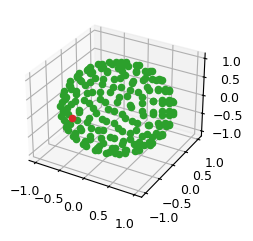

In [15]:
for _ in range(1):
    actions = {
        "Thrust-1": np.array([0, 0, 0, 60]),
        "Thrust-2": np.array([0, 0, 0, 60]),
    }
    # for sat in env.satellites:
    #     if sat.requires_retasking:
    #         if isinstance(sat, TumbleSat):
    #             actions[sat.name] = 0
    #         else:
    #             actions[sat.name] = np.concatenate(
    #                 (np.random.uniform(-20, 20, 3), np.random.uniform(0, 200, 1))
    #             )

    observation, reward, terminated, truncated, info = env.step(actions)

    # print(env.satellites[1].data_store.data.point_inspect_status)
    # print("storage:", observation["Thrust-1"]["sat_props"]["storage_level_fraction"])

fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection="3d"))
for point, inspected in env.satellites[1].data_store.data.point_inspect_status.items():
    # print(point, inspected)
    ax.scatter(*point.r_PB_B, color="tab:green" if inspected else "tab:red")